## Time Series Application

In [1]:
import pandas as pd

finsec_data=pd.read_csv('../feature_engineering/stocks_sectors/financial_services/financial_services_sector')

finsec_data

,date,sector,weighted_sector_returns,n_stocks_contributing,sector_index,sector_volume
0,2017-01-03,financial_services,0.000000,20.0,100.000000,48125518.0
1,2017-01-04,financial_services,0.353432,20.0,100.353432,26705191.0
2,2017-01-05,financial_services,-0.182223,20.0,100.170565,66991076.0
3,2017-01-06,financial_services,1.397196,20.0,101.570144,97521276.0
4,2017-01-09,financial_services,3.645896,20.0,105.273286,99013315.0
...,...,...,...,...,...,...
2258,2026-07-13,financial_services,-0.746327,35.0,2695.019313,290562049.0
2259,2026-07-14,financial_services,0.906947,35.0,2719.461701,163509442.0
2260,2026-07-15,financial_services,0.779799,35.0,2740.668037,258362267.0
2261,2026-07-16,financial_services,1.505893,35.0,2781.939574,261040578.0


In [2]:
finsec_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     2263 non-null   str    
 1   sector                   2263 non-null   str    
 2   weighted_sector_returns  2263 non-null   float64
 3   n_stocks_contributing    2263 non-null   float64
 4   sector_index             2263 non-null   float64
 5   sector_volume            2263 non-null   float64
dtypes: float64(4), str(2)
memory usage: 106.2 KB


In [3]:
## convert date column to datetime
finsec_data['date']=pd.to_datetime(finsec_data['date'],errors='coerce')

finsec_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     2263 non-null   datetime64[us]
 1   sector                   2263 non-null   str           
 2   weighted_sector_returns  2263 non-null   float64       
 3   n_stocks_contributing    2263 non-null   float64       
 4   sector_index             2263 non-null   float64       
 5   sector_volume            2263 non-null   float64       
dtypes: datetime64[us](1), float64(4), str(1)
memory usage: 106.2 KB


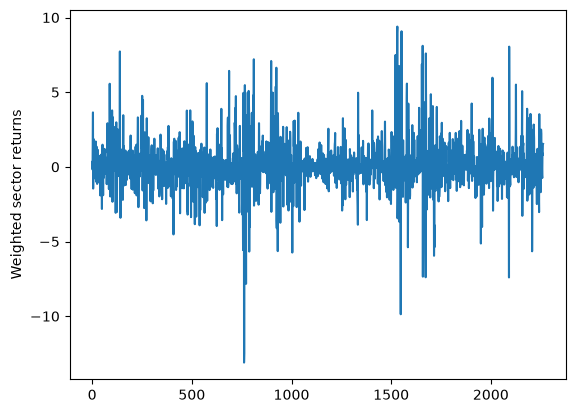

In [4]:
import matplotlib.pyplot as plt
ax=finsec_data['weighted_sector_returns'].plot()
ax.set_ylabel('Weighted sector returns')
plt.show()


In [5]:
## Lets capture seasonality. year, month, quarter
finsec_data['year']=[x.year for x in finsec_data['date']]
finsec_data['month']=[x.month for x in finsec_data['date']]
finsec_data['quarter']=[x.quarter for x in finsec_data['date']]

finsec_data.head()


,date,sector,weighted_sector_returns,n_stocks_contributing,sector_index,sector_volume,year,month,quarter
0,2017-01-03,financial_services,0.000000,20.0,100.000000,48125518.0,2017,1,1
1,2017-01-04,financial_services,0.353432,20.0,100.353432,26705191.0,2017,1,1
2,2017-01-05,financial_services,-0.182223,20.0,100.170565,66991076.0,2017,1,1
3,2017-01-06,financial_services,1.397196,20.0,101.570144,97521276.0,2017,1,1
4,2017-01-09,financial_services,3.645896,20.0,105.273286,99013315.0,2017,1,1


In [6]:
data=finsec_data[['weighted_sector_returns','year','month','quarter']]
data

,weighted_sector_returns,year,month,quarter
0,0.000000,2017,1,1
1,0.353432,2017,1,1
2,-0.182223,2017,1,1
3,1.397196,2017,1,1
4,3.645896,2017,1,1
...,...,...,...,...
2258,-0.746327,2026,7,3
2259,0.906947,2026,7,3
2260,0.779799,2026,7,3
2261,1.505893,2026,7,3


In [7]:
# Create X and y objects
X = data[['year','month','quarter']]
y = data['weighted_sector_returns']

# Create Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, 
random_state=12345,shuffle=False)

# Fit model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

my_lm = LinearRegression()
my_lm.fit(X = X_train, y = y_train)

train_fcst = my_lm.predict(X_train)
test_fcst = my_lm.predict(X_test)

train_r2 = r2_score(y_train, train_fcst)
test_r2 = r2_score(y_test, test_fcst)

print('train_accuracy: ',train_r2,',  test accuracy: ', test_r2)


train_accuracy:  0.000975858279600228 ,  test accuracy:  -0.0036541730039920672


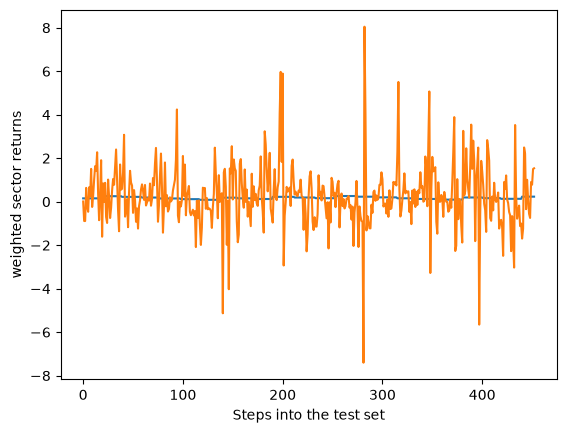

In [8]:
# Plot result
plt.plot(list(test_fcst))
plt.plot(list(y_test))
plt.xlabel('Steps into the test set')
plt.ylabel('weighted sector returns')
plt.show()

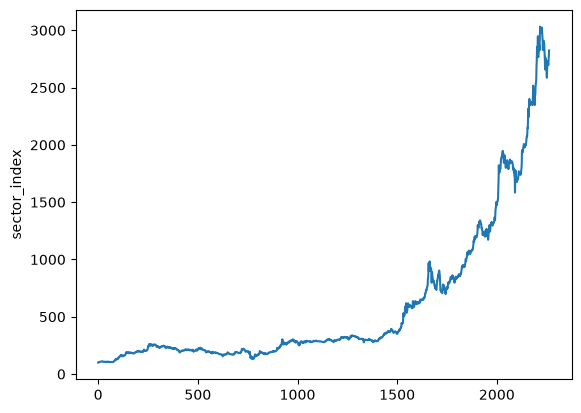

In [9]:
import matplotlib.pyplot as plt
ax=finsec_data['sector_index'].plot()
ax.set_ylabel('sector_index')
plt.show()

In [10]:
# Create X and y objects
X = finsec_data[['year','month','quarter']]
y = finsec_data['sector_index']

# Create Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, 
random_state=12345,shuffle=False)

# Fit model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

my_lm = LinearRegression()
my_lm.fit(X = X_train, y = y_train)

train_fcst = my_lm.predict(X_train)
test_fcst = my_lm.predict(X_test)

train_r2 = r2_score(y_train, train_fcst)
test_r2 = r2_score(y_test, test_fcst)

print('train_accuracy: ',train_r2,',  test accuracy: ', test_r2)


train_accuracy:  0.6490712486257462 ,  test accuracy:  -3.1107656856672543


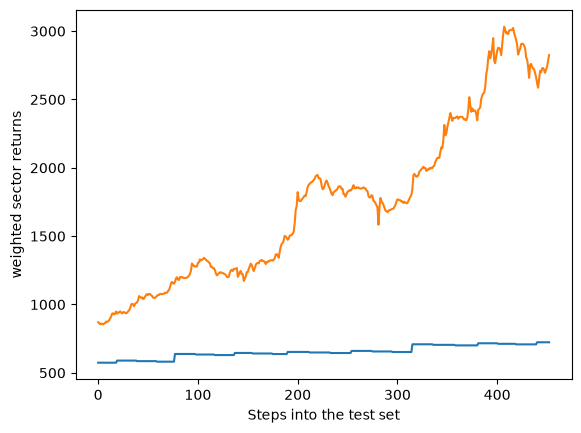

In [11]:
# Plot result
plt.plot(list(test_fcst))
plt.plot(list(y_test))
plt.xlabel('Steps into the test set')
plt.ylabel('weighted sector returns')
plt.show()

In [12]:
# Adding Lagged variable into the data
data['returns_lag1']=data['weighted_sector_returns'].shift(1)
data['returns_lag2']=data['weighted_sector_returns'].shift(2)
data['returns_lag5']=data['weighted_sector_returns'].shift(5)
data['returns_lag10']=data['weighted_sector_returns'].shift(10)
data['returns_lag20']=data['weighted_sector_returns'].shift(20)
data['returns_lag50']=data['weighted_sector_returns'].shift(60)
data['returns_lag100']=data['weighted_sector_returns'].shift(100)
data_lagged=data.dropna()
data_lagged

,weighted_sector_returns,year,month,quarter,returns_lag1,returns_lag2,returns_lag5,returns_lag10,returns_lag20,returns_lag50,returns_lag100
100,3.779650,2017,5,2,2.003486,0.456839,0.417038,-1.345521,2.222708,0.649545,0.000000
101,1.752179,2017,5,2,3.779650,2.003486,-1.147942,-1.986073,1.815887,-1.915182,0.353432
102,-2.338342,2017,5,2,1.752179,3.779650,-0.273027,-0.085779,2.058100,-0.220672,-0.182223
103,2.851446,2017,6,2,-2.338342,1.752179,0.456839,-0.203580,2.170254,0.751944,1.397196
104,3.319720,2017,6,2,2.851446,-2.338342,2.003486,3.223915,-1.488360,0.314921,3.645896
...,...,...,...,...,...,...,...,...,...,...,...
2258,-0.746327,2026,7,3,-0.556971,0.125740,2.204600,-1.123746,-0.622298,1.661408,-3.279374
2259,0.906947,2026,7,3,-0.746327,-0.556971,-0.344068,-1.000082,-2.273895,3.544430,0.589599
2260,0.779799,2026,7,3,0.906947,-0.746327,1.008166,-1.697222,-0.664983,1.511218,2.060890
2261,1.505893,2026,7,3,0.779799,0.906947,0.125740,-1.250020,-1.771346,2.806790,1.394270


In [13]:
# Create X and y objects
X = data_lagged.drop('weighted_sector_returns',axis=1)
y = data_lagged['weighted_sector_returns']

# Create Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, 
random_state=12345,shuffle=False)

# Fit model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

my_lm = LinearRegression()
my_lm.fit(X = X_train, y = y_train)

train_fcst = my_lm.predict(X_train)
test_fcst = my_lm.predict(X_test)

train_r2 = r2_score(y_train, train_fcst)
test_r2 = r2_score(y_test, test_fcst)

print('train_accuracy: ',train_r2,',  test accuracy: ', test_r2)

train_accuracy:  0.037643322773620036 ,  test accuracy:  0.01992862282527874


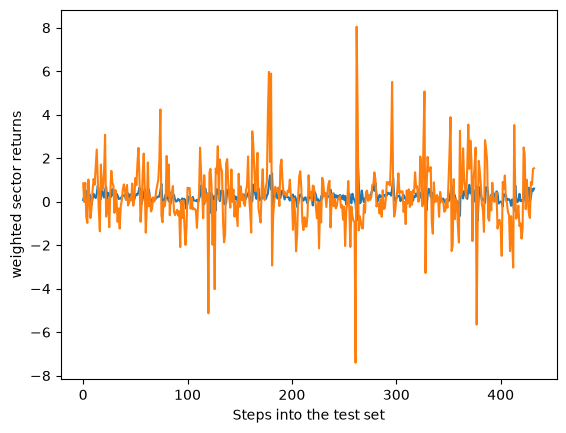

In [14]:
# Plot result
plt.plot(list(test_fcst))
plt.plot(list(y_test))
plt.xlabel('Steps into the test set')
plt.ylabel('weighted sector returns')
plt.show()

Lagging improved the model a bit. Lets lag properly. We will use the function below.

In [15]:
def lag_returns(data: pd.DataFrame,lag_items: list[int] | None = None) -> pd.DataFrame:
    if lag_items is None:
        lag_items=[1]
    for lag in lag_items:
        data[f'lag_return{lag}']=data['weighted_sector_returns'].shift(lag)
    return data

In [16]:
new_data_lag = lag_returns(data=data, lag_items=list(range(1, 201)))


C:\Users\pc\AppData\Local\Temp\ipykernel_14680\2403077405.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'lag_return{lag}']=data['weighted_sector_returns'].shift(lag)


In [17]:
new_data_lag.head()

,weighted_sector_returns,year,month,quarter,returns_lag1,returns_lag2,returns_lag5,returns_lag10,returns_lag20,returns_lag50,...,lag_return191,lag_return192,lag_return193,lag_return194,lag_return195,lag_return196,lag_return197,lag_return198,lag_return199,lag_return200
0,0.000000,2017,1,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.353432,2017,1,1,0.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-0.182223,2017,1,1,0.353432,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.397196,2017,1,1,-0.182223,0.353432,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.645896,2017,1,1,1.397196,-0.182223,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
new_data_lag=new_data_lag.dropna()

In [19]:
# Create X and y objects
X = new_data_lag.drop('weighted_sector_returns',axis=1)
y = new_data_lag['weighted_sector_returns']

# Create Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, 
random_state=12345,shuffle=False)

# Fit model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

my_lm = LinearRegression()
my_lm.fit(X = X_train, y = y_train)

train_fcst = my_lm.predict(X_train)
test_fcst = my_lm.predict(X_test)

train_r2 = r2_score(y_train, train_fcst)
test_r2 = r2_score(y_test, test_fcst)

print('train_accuracy: ',train_r2,',  test accuracy: ', test_r2)

train_accuracy:  0.18132106757295163 ,  test accuracy:  -0.1485783163471437


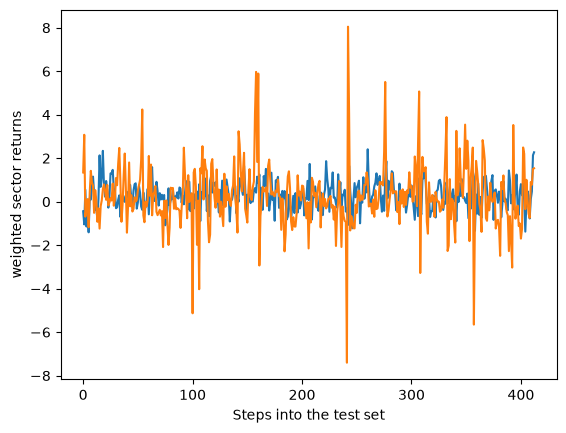

In [20]:
# Plot result
plt.plot(list(test_fcst))
plt.plot(list(y_test))
plt.xlabel('Steps into the test set')
plt.ylabel('weighted sector returns')
plt.show()

I believe a lack of seasonality will really affect the performance because this captures the daily returns. We might want to look at the monthly performance later. For now let us move to AR, MA, ARMA, ARIMA, SARIMA, SARIMAX, VAR and VARMAX.